# SECTION 1 - IMPORTS AND LOADING DATA

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv(r'C:\Data_analyst\project_1\global_freelancers_raw.csv')

# Initial inspection

In [116]:
df.shape

(1000, 12)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [120]:
df.columns.to_list()

['freelancer_ID',
 'name',
 'gender',
 'age',
 'country',
 'language',
 'primary_skill',
 'years_of_experience',
 'hourly_rate (USD)',
 'rating',
 'is_active',
 'client_satisfaction']

In [121]:
df.isna().sum()

freelancer_ID            0
name                     0
gender                   0
age                     30
country                  0
language                 0
primary_skill            0
years_of_experience     51
hourly_rate (USD)       94
rating                 101
is_active               89
client_satisfaction    176
dtype: int64

# SECTION 2 - DATA CLEANING

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


In [123]:
#----gender----

df['gender'] = df['gender'].map(
                                {'f' : 'Female', 
                                 'FEMALE' : 'Female', 
                                 'male' : 'Male', 
                                 'F' : 'Female', 
                                 'female' : 'Female',
                                 'm' : 'Male', 
                                 'MALE' : 'Male', 
                                 'M' : 'Male', 
                                 'Female' : 'Female', 
                                 'Male' : 'Male'})

In [124]:
# ---- hourly_rate (USD) ----

df['hourly_rate (USD)'] = df['hourly_rate (USD)'].str.replace('$', '').str.replace('USD', '')
df['hourly_rate (USD)'] = pd.to_numeric(df['hourly_rate (USD)'])

In [125]:
df['is_active'] = df['is_active'].map({'0' : 'No', '1' : 'Yes', 'N' : 'No', 'False' : 'No', 'True' : 'Yes', 'yes' : 'Yes', 'Y' : 'Yes', 'no' : 'No'})

In [126]:
# ---- client_satisfaction ----

df['client_satisfaction'] = df['client_satisfaction'].str.replace('%', '')
df['client_satisfaction'] = pd.to_numeric(df['client_satisfaction'])

In [127]:
df['is_active'].unique()

array(['No', 'Yes', nan], dtype=object)

<Axes: >

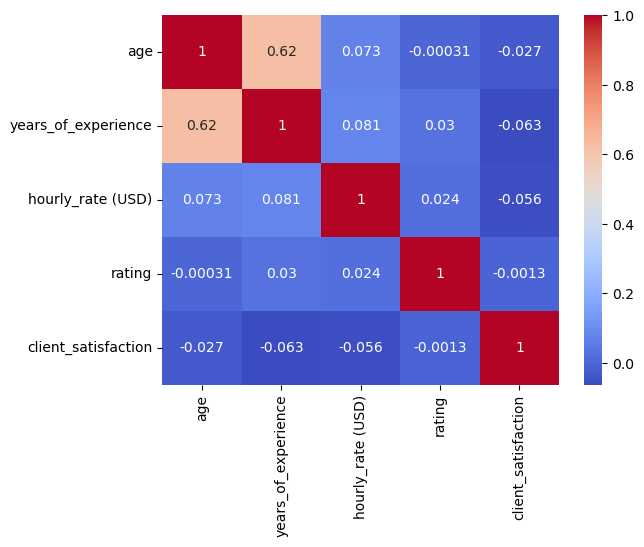

In [128]:
# chacking for relationships between columns 

correlation  = df.corr(numeric_only= True)
sns.heatmap(correlation , annot=True, cmap='coolwarm')

# Nan Handiling 

In [129]:
# age

df['age'] = df['age'].fillna(df['age'].mean())

In [130]:
# years_of_experience 

df['years_of_experience'] = df['years_of_experience'].fillna(df['years_of_experience'].median())

In [131]:
# hourly_rate (USD)

df['hourly_rate (USD)'] = df['hourly_rate (USD)'].fillna(df['hourly_rate (USD)'].median())

In [132]:
# rating

df['rating'] = df['rating'].fillna(df['rating'].mean())

In [133]:
# is_active

df['is_active'] = df['is_active'].fillna(df['is_active'].mode()[0])

In [134]:
# client_satisfaction

df['client_satisfaction'] = df['client_satisfaction'].fillna(df['client_satisfaction'].mean())

In [135]:
df.isna().sum()

freelancer_ID          0
name                   0
gender                 0
age                    0
country                0
language               0
primary_skill          0
years_of_experience    0
hourly_rate (USD)      0
rating                 0
is_active              0
client_satisfaction    0
dtype: int64

# SECTION 3 - EDA WITH NUMBERS

In [136]:
df.corr(numeric_only=True)

,age,years_of_experience,hourly_rate (USD),rating,client_satisfaction
age,1.000000,0.604549,0.069033,-0.000225,-0.024320
years_of_experience,0.604549,1.000000,0.078625,0.025954,-0.055942
hourly_rate (USD),0.069033,0.078625,1.000000,0.022595,-0.047902
rating,-0.000225,0.025954,0.022595,1.000000,-0.001544
client_satisfaction,-0.024320,-0.055942,-0.047902,-0.001544,1.000000


In [137]:
df[['age', 'years_of_experience']].corr()

,age,years_of_experience
age,1.000000,0.604549
years_of_experience,0.604549,1.000000


In [138]:
df.groupby('primary_skill')['hourly_rate (USD)'].mean().sort_values(ascending=False)

primary_skill
Cybersecurity             53.197674
Web Development           52.884615
DevOps                    52.723214
UI/UX Design              51.788991
Machine Learning          51.559140
AI                        51.350000
Data Analysis             51.250000
Mobile Apps               50.490196
Blockchain Development    49.047619
Graphic Design            48.548387
Name: hourly_rate (USD), dtype: float64

In [139]:
df.groupby('country')['hourly_rate (USD)'].mean().sort_values(ascending=False)

country
India             57.555556
Argentina         57.553191
Indonesia         56.521739
United States     55.714286
China             54.693878
Australia         54.411765
Italy             53.452381
Turkey            53.333333
South Africa      52.954545
Germany           51.826923
United Kingdom    51.600000
Canada            49.692308
Egypt             49.642857
France            49.318182
Brazil            48.709677
South Korea       48.529412
Russia            48.085106
Netherlands       47.352941
Mexico            46.900000
Japan             45.945946
Spain             43.222222
Name: hourly_rate (USD), dtype: float64

In [140]:
df.groupby('gender')['hourly_rate (USD)'].mean()

gender
Female    51.908163
Male      50.696078
Name: hourly_rate (USD), dtype: float64

In [141]:
df.groupby('is_active')['rating'].mean()

is_active
No     2.510905
Yes    2.514637
Name: rating, dtype: float64

# SECTION 4 - VISUALIZATIONS

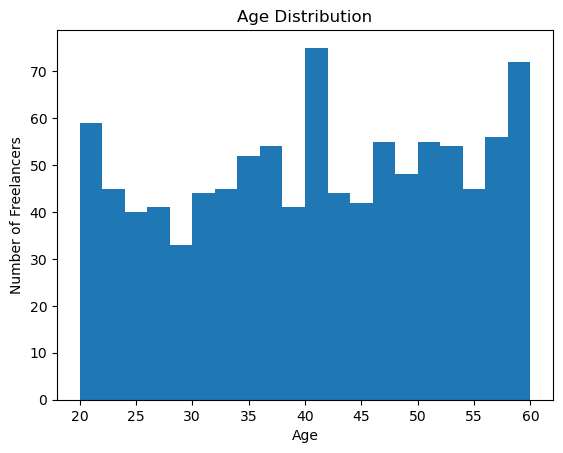

In [142]:
# Chart 1 - Age Distribution
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Freelancers')
plt.show()

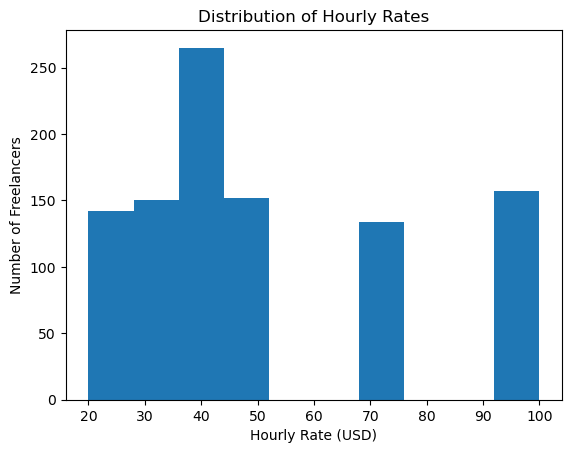

In [143]:
# Chart 2 - Hourly Rate Distribution
plt.hist(df['hourly_rate (USD)'], bins=10)
plt.title('Distribution of Hourly Rates')
plt.xlabel('Hourly Rate (USD)')
plt.ylabel('Number of Freelancers')
plt.show()

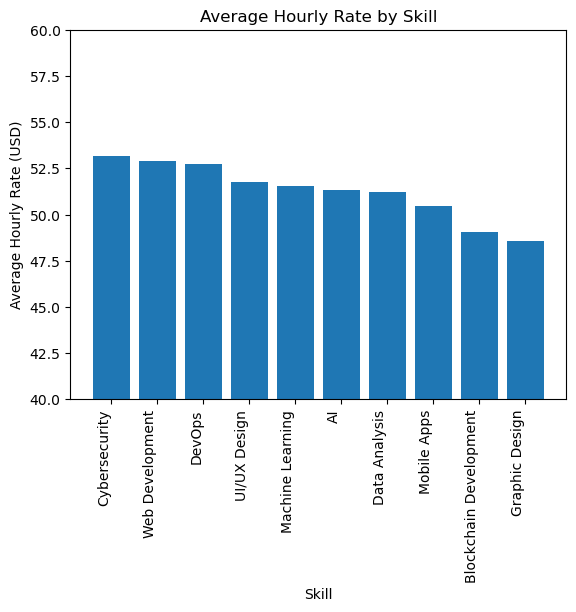

In [144]:
# Chart 3 - Average Hourly Rate by Skill
skill_rate = df.groupby('primary_skill')['hourly_rate (USD)'].mean().sort_values(ascending=False)
plt.bar(skill_rate.index, skill_rate.values)
plt.title('Average Hourly Rate by Skill')
plt.xlabel('Skill')
plt.ylabel('Average Hourly Rate (USD)')
plt.xticks(rotation=90, ha='right')
plt.ylim(40, 60)
plt.show()

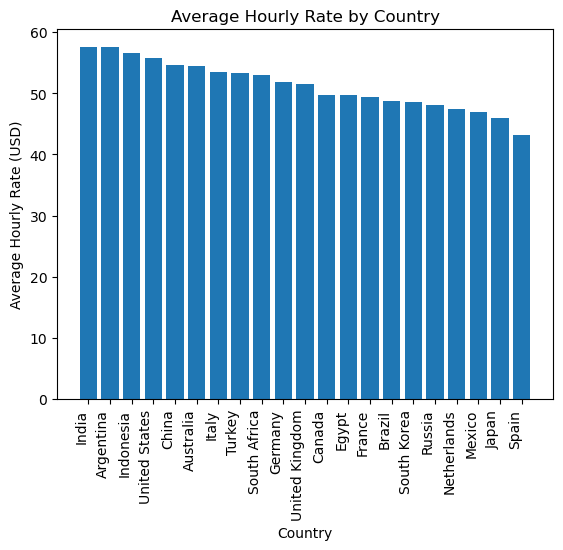

In [145]:
# Chart 4 - Average Hourly Rate by Country
country_rate = df.groupby('country')['hourly_rate (USD)'].mean().sort_values(ascending=False)
plt.bar(country_rate.index, country_rate.values)
plt.title('Average Hourly Rate by Country')
plt.xlabel('Country')
plt.ylabel('Average Hourly Rate (USD)')
plt.xticks(rotation=90, ha='right')
plt.show()

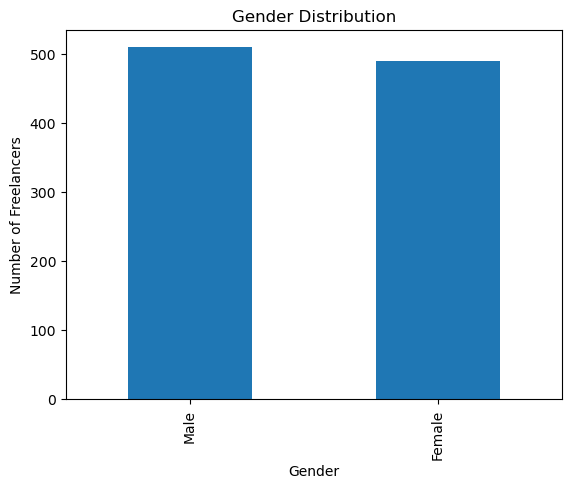

In [146]:
# Chart 5 - Gender Distribution
df['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Freelancers')
plt.show()


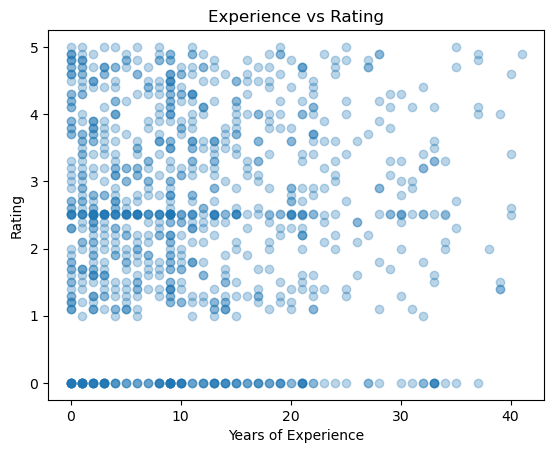

In [147]:
# Chart 6 - Experience vs Rating
plt.scatter(df['years_of_experience'], df['rating'], alpha=0.3)
plt.title('Experience vs Rating')
plt.xlabel('Years of Experience')
plt.ylabel('Rating')
plt.show()

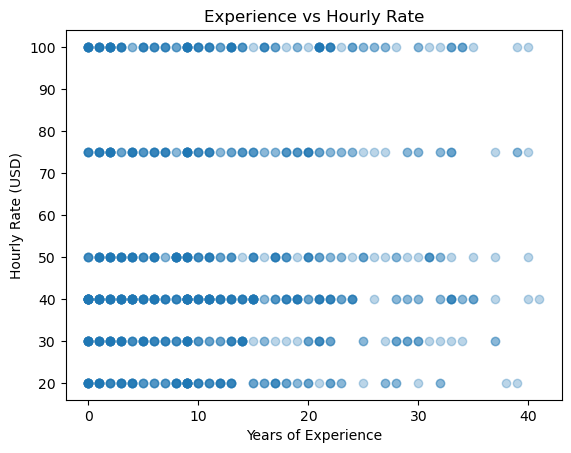

In [148]:
# Chart 7 - Experience vs Hourly Rate
plt.scatter(df['years_of_experience'], df['hourly_rate (USD)'], alpha=0.3)
plt.title('Experience vs Hourly Rate')
plt.xlabel('Years of Experience')
plt.ylabel('Hourly Rate (USD)')
plt.show()


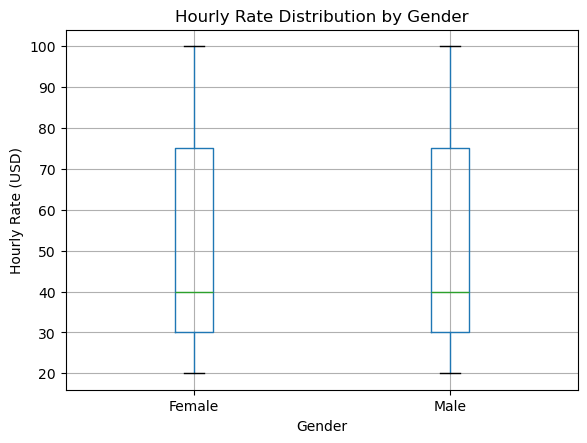

In [149]:
# Chart 8 - Hourly Rate by Gender
df.boxplot(column='hourly_rate (USD)', by='gender')
plt.suptitle('')
plt.title('Hourly Rate Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Hourly Rate (USD)')
plt.show()

# SECTION 5 - KEY FINDINGS

KEY FINDINGS:
1. Dataset appears synthetic - only 6 fixed hourly rates exist
2. Country shows strongest variation in hourly rate ($14 spread)
3. Skill, experience, rating have no meaningful effect on hourly rate
4. 14.5% of freelancers had 0 rating - treated as missing data
5. Age and experience are the only strongly correlated columns (0.624)